In [1]:
import os
import pprint
import argparse
import glob

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))

import pandas as pd
import numpy as np
import cv2
from matplotlib import pyplot as plt
from scipy.spatial import distance

import matplotlib.pyplot as plt
from matplotlib import font_manager

# Register the Lato font
font_dirs = ['/home/chiara/workspace/Lato']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# Set the default font to Lato
plt.rcParams['font.family'] = 'Lato'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'  # Bold the title
plt.rcParams['axes.labelweight'] = 'bold'

%matplotlib inline

In [2]:
os.chdir("/home/chiara/workspace/fetalbiometry_paper/HRNet-Facial-Landmark-Detection-Dev")

In [3]:
def analyze_tta(datatype, anatomy, predictions, OUTPUT_PNG_DIR, df_for_hrnet, display=True):
    meases = []

    df_for_hrnet.drop(df_for_hrnet.columns[0], axis=1, inplace=True)

    # Remove rows where any landmarks are negative
    if anatomy == 'brain' or anatomy == 'abdomen':
        landmark_cols = df_for_hrnet.columns[8:12]
    else:
        landmark_cols = df_for_hrnet.columns[4:8]

    mask = (df_for_hrnet[landmark_cols] < 0).any(axis=1)
    df_for_hrnet = df_for_hrnet[~mask].reset_index(drop=True)

    for j, elem in df_for_hrnet.iterrows():
        sub_pred = predictions[j].cpu().numpy()
        
        # Attempt to read the image in both .png and .jpeg formats
        image_path = os.path.join(OUTPUT_PNG_DIR, elem["image_name"])
        image = cv2.imread(image_path)
        
        if display:
            plt.figure()
            plt.imshow(image)
            plt.title(elem["image_name"])

        x1_point = int(df_for_hrnet.loc[j,datatype.lower()+'_1_x'])
        y1_point = int(df_for_hrnet.loc[j,datatype.lower()+'_1_y'] )
        x2_point = int(df_for_hrnet.loc[j,datatype.lower()+'_2_x'])
        y2_point = int(df_for_hrnet.loc[j,datatype.lower()+'_2_y'] )
        res_pts = sub_pred
        if display:
            plt.title(elem["image_name"], fontsize=18)
            plt.plot( (x1_point, x2_point), (y1_point,y2_point), '#529A21-', label='Ground Truth', linewidth=1.5)
            plt.plot( res_pts[:,0], res_pts[:,1], '#EDC041-', label='Prediction', linewidth=1.5)
        orig_pts = np.array(( (x1_point, x2_point), (y1_point,y2_point)))
        p1, p2 = distance.euclidean(orig_pts.T[0], orig_pts.T[1],) , distance.euclidean(res_pts[0], res_pts[1],)
        pix_size = float(elem["px_to_mm_rate"])
        p1 , p2 = p1 * pix_size, p2*pix_size
        meases.append((p1,p2))#, elem.origalgo))
    return meases

brain: 7.940277190545763
abdomen: 4.097955527997709
femur: 38.36417148239672


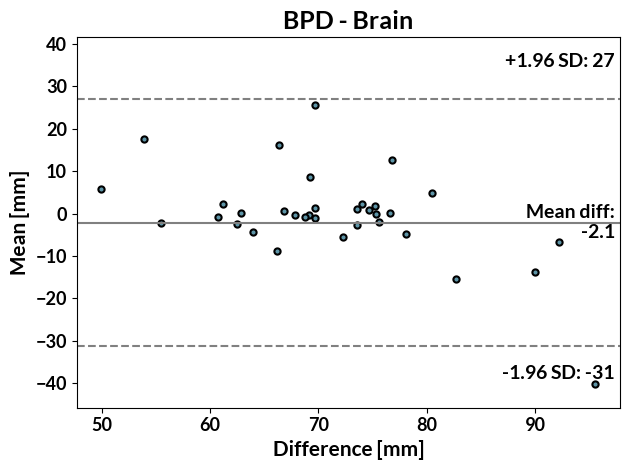

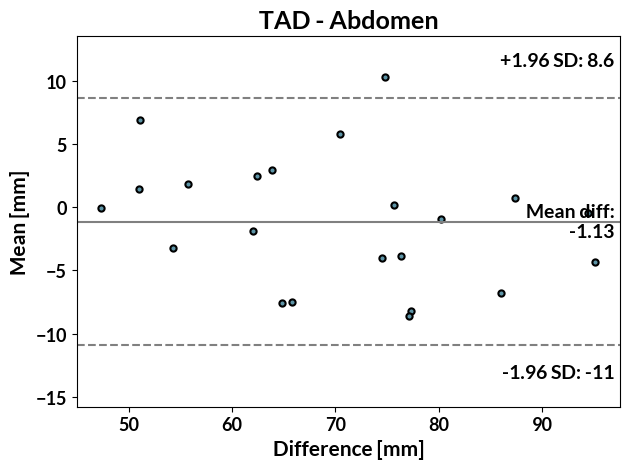

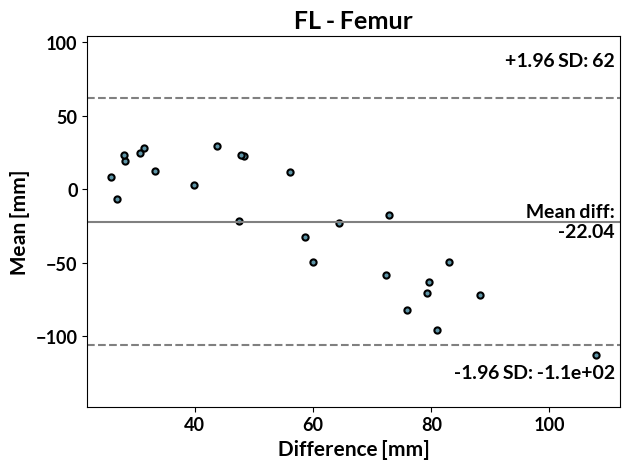

In [4]:
import statsmodels.api as sm

# color_face = '#28607A'
color_face = '#5D94A6'
# color_edge = '#464749'
color_edge = 'black'

# folder = 'FP'
folder = 'UCL'
# folder = 'HC18'

if folder == 'FP':
    keys = ["BPD", "Abdomen", "Femur"]
    anatomies = ["brain", "abdomen", "femur"]
    datatypes = ["bpd", "tad", "fl"]
    display = False
elif folder == 'UCL':
    keys = ["Head", "Abdomen", "Femur"]
    anatomies = ["brain", "abdomen", "femur"]
    datatypes = ["bpd", "tad", "fl"]
    display = False
else:
    keys = ["Head"]
    anatomies = ["brain"]
    datatypes = ["bpd"]
    display = False

for anatomy, key, datatype in zip(anatomies,keys, datatypes):
    predictions = torch.load(f"/home/chiara/workspace/fetalbiometry_paper/HRNet-Facial-Landmark-Detection-Dev/output/FETAL/fetal_landmark_hrnet_w18_{folder}_{anatomy}/predictions.pth")
    OUTPUT_PNG_DIR = f"/home/chiara/workspace/fetalbiometry_paper/fetalbiometrydata/data/{folder}/{key}/"
    df_for_hrnet = pd.read_csv(f"/home/chiara/workspace/fetalbiometry_paper/fetalbiometrydata/{folder}/px_to_mm/{key}_Test.csv")
    results = analyze_tta(datatype, anatomy, predictions, OUTPUT_PNG_DIR, df_for_hrnet, display=display)
    
    curr_fig, curr_ax = plt.subplots()
    mmm = np.array(results)
    sm.graphics.mean_diff_plot(mmm[:,0], mmm[:,1], ax=curr_ax)
    print(f"{anatomy}: {np.mean(np.abs(mmm[:,0] - mmm[:,1]))}")
    for item in curr_ax.collections:
        item.set_color(color_face)
        item.set_edgecolor(color_edge)
        item.set_linewidth(1.5)
    curr_ax.lines[0].set_linewidth(1.5)
    plt.title(f"{datatype.upper()} - {anatomy.capitalize()}", fontsize=18)
    plt.xlabel("Difference [mm]")
    plt.ylabel("Mean [mm]")
    plt.tight_layout()
    plt.savefig(f"/home/chiara/workspace/fetalbiometry_paper/HRNet-Facial-Landmark-Detection-Dev/output/FETAL/{folder}_figs/{datatype.upper()}_{anatomy.capitalize()}.png", format='png', dpi=600)
    plt.savefig(f"/home/chiara/workspace/fetalbiometry_paper/HRNet-Facial-Landmark-Detection-Dev/output/FETAL/{folder}_figs/{datatype.upper()}_{anatomy.capitalize()}.svg", format='svg')
    